# Gas de Esferas Duras en 2D

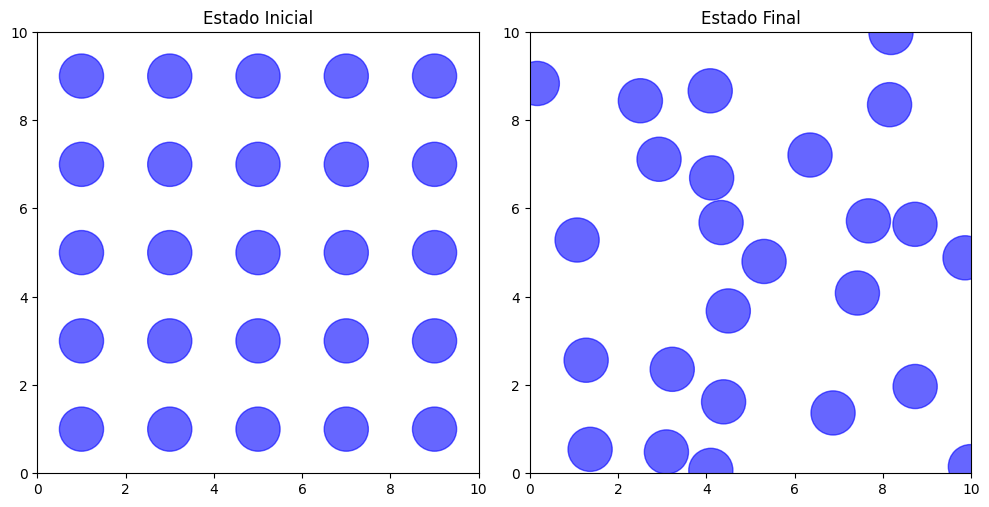

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Red inicial ordenada
def init_grid(N_sqrt, L):
    spacing = L / N_sqrt
    x = np.linspace(spacing/2, L-spacing/2, N_sqrt)
    y = np.linspace(spacing/2, L-spacing/2, N_sqrt)
    xv, yv = np.meshgrid(x, y)
    return np.column_stack((xv.flatten(), yv.flatten()))

# Restricciones físicas
def get_dist_sq(p1, p2, L):
    """Convención de Mínima Imagen."""
    dx = p1[0] - p2[0]
    dy = p1[1] - p2[1]
    # Aplicar PBC y Mínima Imagen
    dx -= L * np.round(dx / L)
    dy -= L * np.round(dy / L)
    return dx**2 + dy**2

def check_overlap(pos, i, L, sigma):
    """Verifica traslape con cualquier otra partícula."""
    sigma_sq = sigma**2
    for j in range(len(pos)):
        if i == j: continue
        if get_dist_sq(pos[i], pos[j], L) < sigma_sq:
            return True
    return False

# Motor Metropolis-Hastings
def run_simulation(N_sqrt, L, sigma, steps, delta, mu_bias=0.0):
    N = N_sqrt**2
    pos = init_grid(N_sqrt, L)
    pos_inicial = np.copy(pos)

    for step in range(steps):
        i = np.random.randint(N)
        old_pos_i = np.copy(pos[i])

        # Propuesta con sesgo (mu_bias)
        dx = mu_bias + np.random.normal(0, delta)
        dy = np.random.normal(0, delta)

        new_pos_i = np.array([(old_pos_i[0] + dx) % L, (old_pos_i[1] + dy) % L])

        # Calcular Factor de Hasting
        hastings_ratio = np.exp(-(mu_bias / delta**2) * dx)

        pos[i] = new_pos_i

        # Verificar Traslape
        if check_overlap(pos, i, L, sigma):
            pos[i] = old_pos_i
        else:
            if np.random.rand() > min(1.0, hastings_ratio):
                pos[i] = old_pos_i

    return pos_inicial, pos

# Visualización
def plot_results(p_ini, p_fin, L, sigma):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    estados = [p_ini, p_fin]
    titulos = ["Estado Inicial", "Estado Final"]

    for ax, pos, title in zip(axes, estados, titulos):
        ax.set_xlim(0, L); ax.set_ylim(0, L)
        ax.set_aspect('equal')
        ax.set_title(title)
        for p in pos:
            ax.add_patch(Circle(p, sigma/2, color='blue', alpha=0.6))
    plt.tight_layout()
    plt.show()

# Ejecución
L, sigma, N_sqrt = 10.0, 1.0, 5
p_ini, p_fin = run_simulation(N_sqrt, L, sigma, steps=20000, delta=0.5, mu_bias=0.0)
plot_results(p_ini, p_fin, L, sigma)

## Tasa de Aceptación

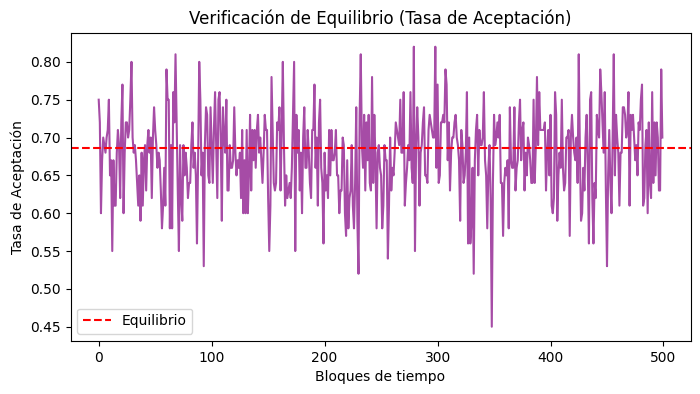

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def run_simulation_with_monitoring(N_sqrt, L, sigma, steps, delta, mu_bias=0.0):
    N = N_sqrt**2
    pos = init_grid(N_sqrt, L)

    # Registro de aceptación para monitorear equilibrio
    history_acceptance = []
    block_size = 100 # tasa cada 100 pasos
    accepted_in_block = 0

    for step in range(steps):
        i = np.random.randint(N)
        old_pos_i = np.copy(pos[i])

        # Propuesta
        dx = mu_bias + np.random.normal(0, delta)
        dy = np.random.normal(0, delta)
        new_pos_i = np.array([(old_pos_i[0] + dx) % L, (old_pos_i[1] + dy) % L])

        hastings_ratio = np.exp(-(mu_bias / delta**2) * dx)

        # Traslape
        pos[i] = new_pos_i
        if check_overlap(pos, i, L, sigma):
            pos[i] = old_pos_i
        else:
            if np.random.rand() < min(1.0, hastings_ratio):
                accepted_in_block += 1
            else:
                pos[i] = old_pos_i

        # Registrar tasa
        if (step + 1) % block_size == 0:
            history_acceptance.append(accepted_in_block / block_size)
            accepted_in_block = 0

    return history_acceptance

# Ejecucuión y Visualización
steps = 50000
acc_rate = run_simulation_with_monitoring(5, 10.0, 1.0, steps, 0.5)

plt.figure(figsize=(8, 4))
plt.plot(acc_rate, color='purple', alpha=0.7)
plt.axhline(y=np.mean(acc_rate[-50:]), color='red', linestyle='--', label='Equilibrio')
plt.title("Verificación de Equilibrio (Tasa de Aceptación)")
plt.xlabel("Bloques de tiempo")
plt.ylabel("Tasa de Aceptación")
plt.legend()
plt.show()

# Estudio de los observables

## Función de Distribución Radial

<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3155/2268687985.py:32: SyntaxWarning: invalid escape sequence '\s'
  plt.axvline(sigma, color='red', linestyle='--', label='Diámetro $\sigma$')


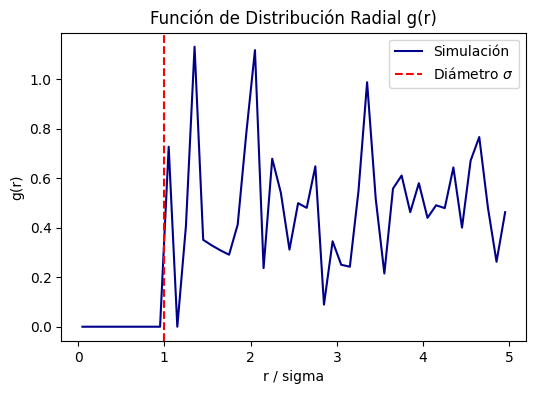

In [10]:
def calcular_g_r(pos, L, sigma, bins=50):
    """
    Calcula la función de distribución radial g(r).
    """
    N = len(pos)
    rho = N / (L**2)
    distancias = []

    # Calcular distancias entre todos los pares sin repetir
    for i in range(N):
        for j in range(i + 1, N):
            d2 = get_dist_sq(pos[i], pos[j], L)
            distancias.append(np.sqrt(d2))

    r_max = L / 2
    hist, edges = np.histogram(distancias, bins=bins, range=(0, r_max))
    r = (edges[:-1] + edges[1:]) / 2
    dr = edges[1] - edges[0]

    # Normalización
    # Se divide por el área de la corona circular
    shell_area = 2 * np.pi * r * dr
    g_r = hist / (N * rho * shell_area)

    return r, g_r

# Ejecución y Visualización
r_axis, gr = calcular_g_r(p_fin, L, sigma)

plt.figure(figsize=(6, 4))
plt.plot(r_axis, gr, label='Simulación', color='darkblue')
plt.axvline(sigma, color='red', linestyle='--', label='Diámetro $\sigma$')
plt.title("Función de Distribución Radial g(r)")
plt.xlabel("r / sigma")
plt.ylabel("g(r)")
plt.legend()
plt.show()

## Energía y Velocidad vs Temperatura

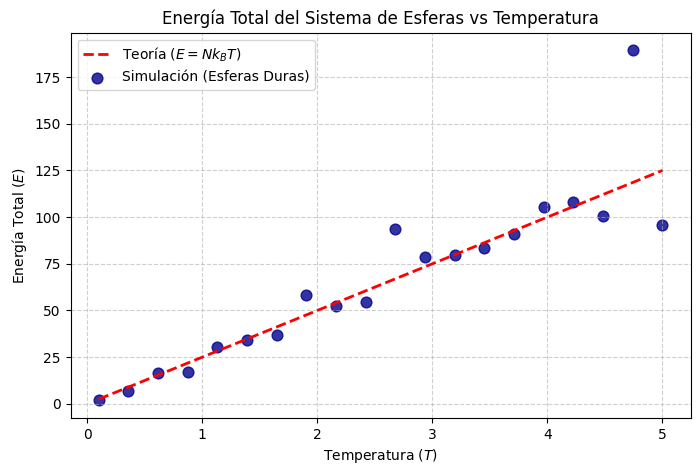

In [11]:
# Termodinámica del sistema

def calcular_energia_sistema(posiciones, T, m=1.0, kB=1.0):

    N = len(posiciones)

    # Asignar velocidades a las esferas según la temperatura T
    std_dev = np.sqrt(kB * T / m)
    vx = np.random.normal(0, std_dev, N)
    vy = np.random.normal(0, std_dev, N)

    # Calcular Energía Cinética
    K_total = np.sum(0.5 * m * (vx**2 + vy**2))

    # Energía Potencial
    U_total = 0.0

    # Energía Total
    E_total = K_total + U_total

    # Energía Teórica
    E_teorica = N * kB * T

    return E_total, E_teorica

# Estudio
T_range = np.linspace(0.1, 5.0, 20)

E_simulada = []
E_teorica_lista = []

for T in T_range:
    E_sim, E_teo = calcular_energia_sistema(p_fin, T)
    E_simulada.append(E_sim)
    E_teorica_lista.append(E_teo)

# Visualización
plt.figure(figsize=(8, 5))

plt.plot(T_range, E_teorica_lista, 'r--', linewidth=2, label='Teoría ($E = N k_B T$)')

plt.scatter(T_range, E_simulada, color='darkblue', s=60, alpha=0.8, label='Simulación (Esferas Duras)')

plt.title("Energía Total del Sistema de Esferas vs Temperatura")
plt.xlabel("Temperatura ($T$)")
plt.ylabel("Energía Total ($E$)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3155/579695415.py:32: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(T_range, v_teoricas, 'r--', linewidth=2, label='Teoría ($v = \sqrt{2 k_B T / m}$)')


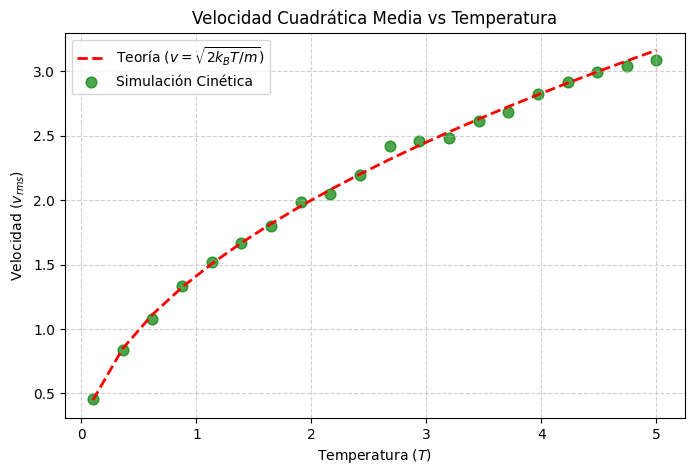

In [12]:
# Termodinamica del sistema

def calcular_velocidad_sistema(T, m=1.0, kB=1.0):
    """
    Calcula la velocidad rms simulada y teórica para una temperatura T.
    """
    # velocidades
    std_dev = np.sqrt(kB * T / m)
    vx = np.random.normal(0, std_dev, 1000)
    vy = np.random.normal(0, std_dev, 1000)

    # Velocidad magnitud media cuadrática
    v_rms_sim = np.sqrt(np.mean(vx**2 + vy**2))

    # Velocidad teórica
    v_rms_teo = np.sqrt(2 * kB * T / m)

    return v_rms_sim, v_rms_teo

# Ejecución
T_range = np.linspace(0.1, 5.0, 20)
v_simuladas = []
v_teoricas = []

for T in T_range:
    v_sim, v_teo = calcular_velocidad_sistema(T)
    v_simuladas.append(v_sim)
    v_teoricas.append(v_teo)

# Visualización
plt.figure(figsize=(8, 5))
plt.plot(T_range, v_teoricas, 'r--', linewidth=2, label='Teoría ($v = \sqrt{2 k_B T / m}$)')
plt.scatter(T_range, v_simuladas, color='green', s=60, alpha=0.7, label='Simulación Cinética')

plt.title("Velocidad Cuadrática Media vs Temperatura")
plt.xlabel("Temperatura ($T$)")
plt.ylabel("Velocidad ($v_{rms}$)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Distribución de Maxwell-Boltzmann

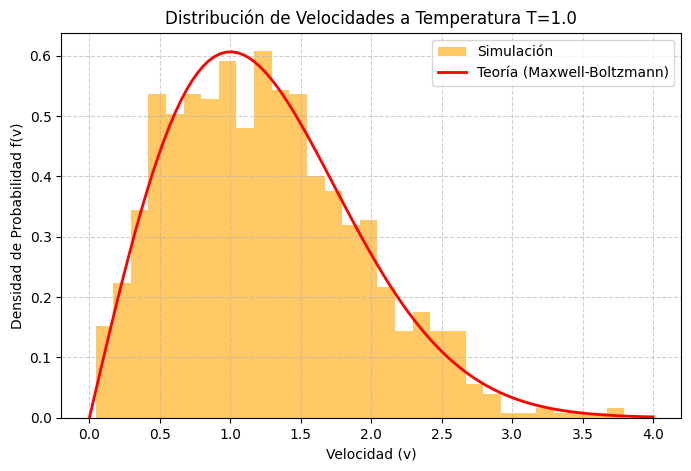

In [13]:
# MAXWELL-BOLTZMAN

def plot_maxwell_boltzmann(T, N=1000, m=1.0, kB=1.0):
    # Generar velocidades simuladas
    std_dev = np.sqrt(kB * T / m)
    vx = np.random.normal(0, std_dev, N)
    vy = np.random.normal(0, std_dev, N)
    v = np.sqrt(vx**2 + vy**2)

    # Distribución teórica
    v_range = np.linspace(0, 4 * std_dev, 100)
    f_v = (m * v_range / (kB * T)) * np.exp(-m * v_range**2 / (2 * kB * T))

    # Ploteo
    plt.figure(figsize=(8, 5))
    plt.hist(v, bins=30, density=True, alpha=0.6, color='orange', label='Simulación')
    plt.plot(v_range, f_v, 'r-', linewidth=2, label='Teoría (Maxwell-Boltzmann)')

    plt.title(f"Distribución de Velocidades a Temperatura T={T}")
    plt.xlabel("Velocidad (v)")
    plt.ylabel("Densidad de Probabilidad f(v)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

plot_maxwell_boltzmann(T=1.0)